In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Veriyi oku
df = pd.read_csv('ai4i2020.csv')

# Tahmin edilecek hedef (y): Tork, Kullanılacak özellikler (X): Diğer sensörler
X = df[['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Tool wear [min]']]
y = df['Torque [Nm]']

# Veriyi %80 Eğitim, %20 Test olarak böl
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("✅ Veri hazırlandı. Eğitim seti boyutu:", X_train.shape)

C:\Users\ibrah\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\ibrah\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


✅ Veri hazırlandı. Eğitim seti boyutu: (8000, 4)


In [2]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

# Denenecek parametreler (AutoML mantığı)
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10]
}

rf = RandomForestRegressor(random_state=42)
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=3, scoring='r2')
grid_search.fit(X_train, y_train)

# En iyi modeli seç
best_reg_model = grid_search.best_estimator_
print(" En iyi parametreler bulundu:", grid_search.best_params_)

 En iyi parametreler bulundu: {'max_depth': 10, 'n_estimators': 100}


In [3]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

y_pred = best_reg_model.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f" Model Başarı Skoru (R2): {r2:.4f}")
print(f" Hata Payı (RMSE): {rmse:.4f}")

 Model Başarı Skoru (R2): 0.8342
 Hata Payı (RMSE): 4.0419


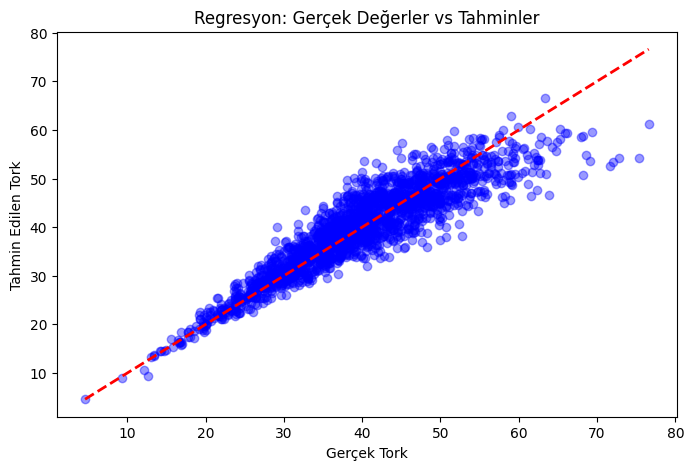

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.4, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Gerçek Tork')
plt.ylabel('Tahmin Edilen Tork')
plt.title('Regresyon: Gerçek Değerler vs Tahminler')
plt.show()

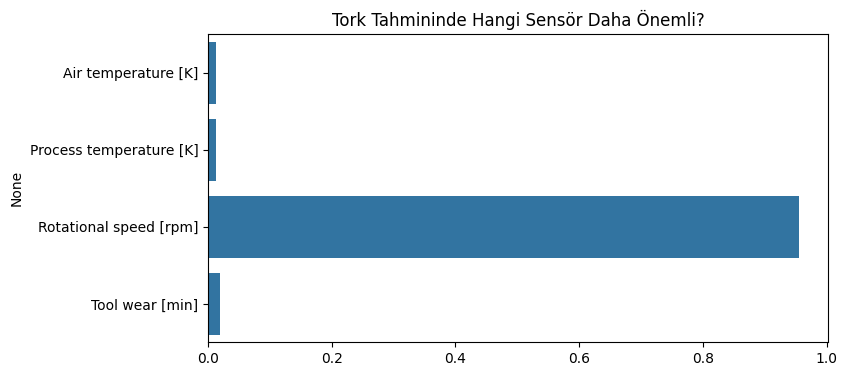

In [5]:
import seaborn as sns

importances = best_reg_model.feature_importances_
feature_names = X.columns

plt.figure(figsize=(8, 4))
sns.barplot(x=importances, y=feature_names)
plt.title('Tork Tahmininde Hangi Sensör Daha Önemli?')
plt.show()